# Portfolio Optimization
Based on quality_score, dividend, signal type ..

## 1. Loading the company_score.csv

In [65]:
import pandas as pd
import numpy as np

df_scores = pd.read_csv("../results/company_scores.csv")
print(f"total companies: {len(df_scores)}")
df_scores

total companies: 1


,company,avg_score,avg_dividend,signal,last_close
0,NABIL,0.472,16.07,Neutral,496.7


In [66]:
#filtering the bullish and neutral signal
eligible = df_scores[df_scores['signal'] != 'Bearish'].copy()
eligible = eligible.sort_values('avg_score', ascending=False).reset_index(drop=True)

print(f"\nEligible Companies ({len(eligible)}):")
print(eligible[['company', 'avg_score', 'avg_dividend', 'last_close', 'signal']])



Eligible Companies (1):
  company  avg_score  avg_dividend  last_close   signal
0   NABIL      0.472         16.07       496.7  Neutral


In [67]:
# Separate for reference
bullish_count = len(eligible[eligible['signal'] == 'Bullish'])
neutral_count = len(eligible[eligible['signal'] == 'Neutral'])
print(f"\n  Bullish: {bullish_count} companies")
print(f"  Neutral: {neutral_count} companies")


  Bullish: 0 companies
  Neutral: 1 companies


In [68]:
if len(eligible) == 0:
    print("No eligible companies found. Run quality score notebooks first.")
    raise SystemExit

elif len(eligible) == 1:
    print(f"\nOnly 1 eligible company found: {eligible['company'].iloc[0]}")
    print("Diversification not possible. All capital will be allocated to this company.")
    num_companies = 1
    MAX_WEIGHT = 1.0   # no cap needed

else:
    # Normal flow — ask user for number of companies
    num_companies = int(input("Enter number of companies to invest in: "))
    if num_companies > len(eligible):
        print(f"Only {len(eligible)} eligible companies. Setting to {len(eligible)}.")
        num_companies = len(eligible)
    elif num_companies < 2:
        print("Minimum 2 companies required for diversification. Setting to 2.")
        num_companies = 2
    MAX_WEIGHT = 0.40


Only 1 eligible company found: NABIL
Diversification not possible. All capital will be allocated to this company.


## 2. User Input

In [69]:
print("=" * 45)
print("        NEPSE PORTFOLIO OPTIMIZER")
print("=" * 45)

capital     = float(input("\nEnter total capital (NPR): "))
num_companies = int(input("Enter number of companies to invest in: "))

# Validate against available eligible companies
if num_companies > len(eligible):
    print(f"Only {len(eligible)} eligible companies available. Setting to {len(eligible)}.")
    num_companies = len(eligible)
elif num_companies < 2:
    print("Minimum 2 companies required for diversification. Setting to 2.")
    num_companies = 2

print("\nChoose Portfolio Strategy:")
print("  [1] High Risk   / High Return")
print("  [2] Low Risk    / Medium Return")
print("  [3] Balanced    / Average Return")

strategy = input("\nEnter choice (1/2/3): ").strip()

if strategy not in ['1', '2', '3']:
    print("Invalid strategy. Please enter 1, 2, or 3.")
else:
    strategy_names = {
        '1': 'HIGH RISK / HIGH RETURN',
        '2': 'LOW RISK / MEDIUM RETURN',
        '3': 'BALANCED PORTFOLIO'
    }
    print(f"\nSelected   : {strategy_names[strategy]}")
    print(f"Capital    : NPR {capital:,.2f}")
    print(f"Companies  : {num_companies}")

        NEPSE PORTFOLIO OPTIMIZER



Enter total capital (NPR):  100000
Enter number of companies to invest in:  10


Only 1 eligible companies available. Setting to 1.

Choose Portfolio Strategy:
  [1] High Risk   / High Return
  [2] Low Risk    / Medium Return
  [3] Balanced    / Average Return



Enter choice (1/2/3):  1



Selected   : HIGH RISK / HIGH RETURN
Capital    : NPR 100,000.00
Companies  : 1


## 3. Scoring and Weight Calculation

In [70]:
def normalize(series):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([1/len(series)] * len(series), index=series.index)
    return (series - mn) / (mx - mn)

# Normalize avg_score and avg_dividend
eligible['score_norm']    = normalize(eligible['avg_score'])
eligible['dividend_norm'] = normalize(eligible['avg_dividend'])


In [71]:

#strategies 1: high risk, high return
eligible['high_risk_weight'] = (eligible['score_norm'] * 0.80 +
                                eligible['dividend_norm'] * 0.20)

# Strategy 2: Low Risk — prioritize dividend + stable QS
eligible['low_risk_weight'] = (
    eligible['dividend_norm'] * 0.60 +
    eligible['score_norm']    * 0.40
)

# Strategy 3: Balanced — equal mix
eligible['balanced_weight'] = (
    eligible['score_norm']    * 0.50 +
    eligible['dividend_norm'] * 0.50
)

In [72]:

# Select weight column based on strategy
weight_map = {
    '1': 'high_risk_weight',
    '2': 'low_risk_weight',
    '3': 'balanced_weight'
}
selected_weight = weight_map[strategy]
selected_weight

'high_risk_weight'

In [73]:
# Normalize selected weights to sum to 1
eligible['final_weight'] = (
    eligible[selected_weight] / eligible[selected_weight].sum()
).round(4)

In [74]:
# Keep only top N companies based on avg_score
eligible = eligible.head(num_companies).copy()
print("Weight Distribution:")
print(eligible[['company', 'signal', 'avg_score', 'avg_dividend', 'final_weight']])
print(f"\nTotal Weight: {eligible['final_weight'].sum():.4f}")

Weight Distribution:
  company   signal  avg_score  avg_dividend  final_weight
0   NABIL  Neutral      0.472         16.07           1.0

Total Weight: 1.0000


## 4. Diversification Concept

In [75]:
# Diversification cap: no single stock exceeds 45% of portfolio
MAX_WEIGHT =  0.45

def apply_diversification(weights_series):
    weights = weights_series / weights_series.sum()
    
    # Iteratively cap and redistribute until all weights are within limit
    for _ in range(100):
        excess = weights[weights > MAX_WEIGHT] - MAX_WEIGHT
        if excess.empty:
            break
        weights[weights > MAX_WEIGHT] = MAX_WEIGHT
        uncapped = weights[weights < MAX_WEIGHT]
        if uncapped.empty:
            break
        weights[uncapped.index] += excess.sum() * (uncapped / uncapped.sum())
    
    return (weights / weights.sum()).round(4)

In [76]:
# Apply diversification to selected weight
eligible['final_weight'] = apply_diversification(eligible[selected_weight])

# Capital allocated per company
eligible['allocated_capital'] = (eligible['final_weight'] * capital).round(2)

# Shares to buy 
eligible['shares_to_buy'] = (eligible['allocated_capital'] / eligible['last_close']).astype(int)


In [77]:
eligible

,company,avg_score,avg_dividend,signal,last_close,score_norm,dividend_norm,high_risk_weight,low_risk_weight,balanced_weight,final_weight,allocated_capital,shares_to_buy
0,NABIL,0.472,16.07,Neutral,496.7,1.0,1.0,1.0,1.0,1.0,1.0,100000.0,201


In [78]:
# Actual amount invested 
eligible['amount_invested'] = (eligible['shares_to_buy'] * eligible['last_close']).round(2)

# Remaining cash per company 
eligible['remaining_cash'] = (eligible['allocated_capital'] - eligible['amount_invested']).round(2)

# Expected annual dividend income
eligible['dividend_income'] = (eligible['shares_to_buy'] * eligible['avg_dividend']).round(2)

In [79]:
# Summary
total_invested    = eligible['amount_invested'].sum()
total_dividend    = eligible['dividend_income'].sum()
total_remaining   = capital - total_invested

print("\nAllocation Details:")
print(eligible[['company', 'signal', 'final_weight',
                'shares_to_buy', 'last_close',
                'amount_invested', 'dividend_income']].to_string(index=False))

print(f"\n{'='*50}")
print(f"  Total Capital             : NPR {capital:,.2f}")
print(f"  Total Invested            : NPR {total_invested:,.2f}")
print(f"  Remaining Cash            : NPR {total_remaining:,.2f}")
print(f"  Est. Annual Dividend      : NPR {total_dividend:,.2f}")
print(f"  Portfolio Utilization     : {(total_invested/capital)*100:.1f}%")
print(f"{'='*50}")


Allocation Details:
company  signal  final_weight  shares_to_buy  last_close  amount_invested  dividend_income
  NABIL Neutral           1.0            201       496.7          99836.7          3230.07

  Total Capital             : NPR 100,000.00
  Total Invested            : NPR 99,836.70
  Remaining Cash            : NPR 163.30
  Est. Annual Dividend      : NPR 3,230.07
  Portfolio Utilization     : 99.8%


## Step 5 : Visualization

### i. Pie chart For weight distribution

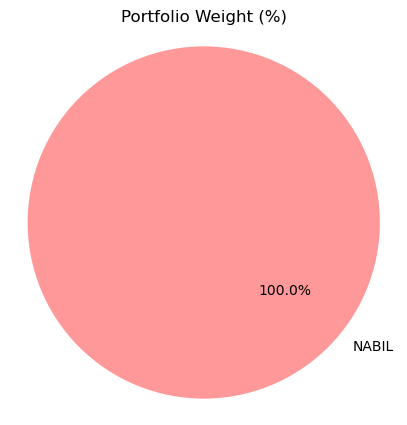

In [80]:
import matplotlib.pyplot as plt

# 1. Setup Data
labels = eligible['company']
sizes = eligible['final_weight']
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99'] # Simple distinct colors

# 2. Create Plot
plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)

# 3. Add Title and Show
plt.title('Portfolio Weight (%)')
plt.axis('equal')
plt.savefig('../results/plots/portfolio_weights.png', dpi=300)
plt.show()

### ii. Quantity of Shares to buy

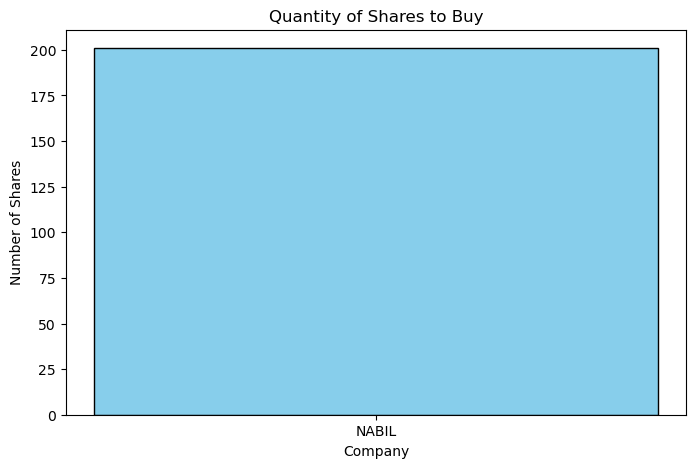

In [81]:
import matplotlib.pyplot as plt

# 1. Setup Data
companies = eligible['company']
shares = eligible['shares_to_buy']

plt.figure(figsize=(8, 5))
plt.bar(companies, shares, color='skyblue', edgecolor='black')
plt.title('Quantity of Shares to Buy')
plt.xlabel('Company')
plt.ylabel('Number of Shares')
plt.savefig('../results/plots/shares_to_buy.png', dpi=300)
plt.show()

### Step 6 : Save Portfolio to CSV

In [84]:
import os

# Select only relevant columns to save
portfolio_output = eligible[[
    'company',
    'signal',
    'avg_score',
    'avg_dividend',
    'last_close',
    'final_weight',
    'allocated_capital',
    'shares_to_buy',
    'amount_invested',
    'dividend_income'
]].copy()

# Add strategy label
portfolio_output['strategy'] = strategy_names[strategy]

output_path = f'../results/portfolio_strategy_{strategy}.csv'

portfolio_output.to_csv(output_path, index=False)

print(f"Portfolio saved to: {output_path}")

Portfolio saved to: ../results/portfolio_strategy_1.csv
